In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import os
import matplotlib.pyplot as plt

In [ ]:
os.listdir("DPO/System1"), len(os.listdir("DPO/System1"))

(['dpo - addsub.csv',
  'dpo - strategy.csv',
  'dpo - multi.csv',
  'dpo - aqua.csv',
  'dpo - letter.csv',
  'dpo - object.csv',
  'dpo - svamp.csv',
  'dpo - coin.csv',
  'dpo - single.csv',
  'dpo - gsm.csv',
  'dpo - common.csv'],
 11)

In [ ]:
strategies = ["System1", "System2"]
alignment_techniques = ["dpo", "simpo"]
benchmarks = [
    "strategy",
    "addsub",
    "gsm",
    "single",
    "aqua",
    "common",
    "svamp",
    "multi",
    "coin",
    "letter"
]

type_of_questions = {
    "common": "Common Sense",
    "strategy": "Common Sense",
    "coin": "Symbolic",
    "letter": "Symbolic",
    "addsub": "Arithmetic",
    "gsm": "Arithmetic",
    "single": "Arithmetic",
    "aqua": "Arithmetic",
    "svamp": "Arithmetic",
    "multi": "Arithmetic",
}

number_of_new_lines = {
    "addsub": 1,
    "aqua": 1,
    "common": 1,
    "gsm": 1,
    "strategy": 1,
    "letter": 1,
    "single": 1,
    "svamp": 1,
    "coin": 1,
    "multi": 1
}

In [ ]:
alignment_technique_index = 0

alignment_technique = alignment_techniques[alignment_technique_index]

print("Alignment technique:", alignment_technique)

Alignment technique: dpo


In [ ]:
# import the package to use to print with color
from termcolor import colored


def show_datapoint(row):
    print("Question:\n", row["sys1_question"])
    print("---------------------")
    print("Answer:\n", row["sys2_GT"])
    print("---------------------")
    print("Sys2 Answer:\n", row["sys2_answer"])
    print("---------------------")
    print("Sys2 Final Answer:\n", row["sys2_pred_after"])
    print("---------------------")
    print("Sys2 text:\n", colored(row["sys2_input"], "red"))
    print("---------------------")
    print("Sys1 Answer:\n", row["sys1_answer"])
    print("---------------------")
    print("Sys1 Final Answer:\n", row["sys1_pred_after"])
    print("---------------------")
    print("Sys1 text:\n", colored(row["sys1_input"], "red"))
    print("---------------------")

In [ ]:
all_datasets_df = None

for benchmark in benchmarks:

    file_name_system1 = os.path.join(
        alignment_technique.upper(),
        strategies[0],
        f"{alignment_technique} - {benchmark}.csv",
    )
    file_name_system2 = os.path.join(
        alignment_technique.upper(),
        strategies[1],
        f"{alignment_technique} - {benchmark}.csv",
    )

    sys1_data = pd.read_csv(file_name_system1)
    sys2_data = pd.read_csv(file_name_system2)

    # for columns pred_after and GT, if either is float, convert both to float
    # otherwise, convert both to string

    sys1_data = sys1_data.rename(
        columns={col: f"sys1_{col}" for col in sys1_data.columns}
    )
    sys2_data = sys2_data.rename(
        columns={col: f"sys2_{col}" for col in sys2_data.columns}
    )

    merged_data = pd.concat([sys1_data, sys2_data], axis=1)
    merged_data["benchmark"] = benchmark
    merged_data["ability"] = type_of_questions[benchmark]
    merged_data = merged_data.rename(
        columns={
            "sys1_pred_before": "sys1_second_answer",
            "sys2_pred_before": "sys2_second_answer",
        }
    )

    if all_datasets_df is None:
        all_datasets_df = merged_data
    else:
        all_datasets_df = pd.concat([all_datasets_df, merged_data], axis=0)

In [ ]:
all_datasets_df.head()

,sys1_input,sys1_second_answer,sys1_pred_after,sys1_GT,sys2_input,sys2_second_answer,sys2_pred_after,sys2_GT,benchmark,ability
0,Is it common to see frost during some college ...,Yes,yes,yes,Is it common to see frost during some college ...,No. While it's not impossible to see frost dur...,no,yes,strategy,Common Sense
1,Hydrogen's atomic number squared exceeds numbe...,A clever question!\n\nAnd a correct answer!\n\...,no,no,Hydrogen's atomic number squared exceeds numbe...,A clever question indeed!\n\nYou've correctly ...,no,no,strategy,Common Sense
2,Would a pear sink in water?\nA pear is a type ...,Yes. A pear will sink in water due to its dens...,yes,no,"Would a pear sink in water?\nA pear, being a t...","**No**\n\nAccording to the calculation, since ...",no,no,strategy,Common Sense
3,Do hamsters provide food for any animals?\nYes...,Yes,yes,yes,Do hamsters provide food for any animals?\nWha...,While hamsters themselves are not a significan...,yes,yes,strategy,Common Sense
4,Are all limbs required for jujutsu?\nIn tradit...,"No. According to the text, all limbs are not r...",no,no,Are all limbs required for jujutsu?\nIn tradit...,"No. According to the text, while limbs can be ...",no,no,strategy,Common Sense


In [ ]:
print(
    "Number of NaNs in pred_after for sys2:",
    all_datasets_df["sys2_pred_after"].isna().sum(),
)
print(
    "Number of NaNs in pred_after for sys1:",
    all_datasets_df["sys1_pred_after"].isna().sum(),
)

Number of NaNs in pred_after for sys2: 288
Number of NaNs in pred_after for sys1: 92


In [ ]:
# performance of sys1 using the sys1_GT and sys1_pred_after
print(
    "Performance of sys1 using the sys1_GT and sys1_pred_after",
    all_datasets_df[
        all_datasets_df["sys1_GT"] == all_datasets_df["sys1_pred_after"]
    ].shape[0]
    / all_datasets_df.shape[0],
)
print(
    "Performance of sys2 using the sys2_GT and sys2_pred_after",
    all_datasets_df[
        all_datasets_df["sys2_GT"] == all_datasets_df["sys2_pred_after"]
    ].shape[0]
    / all_datasets_df.shape[0],
)

Performance of sys1 using the sys1_GT and sys1_pred_after 0.7687201583789449
Performance of sys2 using the sys2_GT and sys2_pred_after 0.7703505298707348


In [ ]:
def extract_question(text):
    number_of_new_lines_in_benchmark = number_of_new_lines[benchmark]
    return "\n".join(text.split("\n")[:number_of_new_lines_in_benchmark])


def extract_first_answer(text):
    number_of_new_lines_in_benchmark = number_of_new_lines[benchmark]
    return "\n".join(text.split("\n")[number_of_new_lines_in_benchmark:])


def extract_final_answer_sys1(row):
    # append the first_answer which is sys1_first_answer to sys1_pred_before to get the final answer
    return f"{row['sys1_first_answer']}\n{row['sys1_second_answer']}"


def extract_final_answer_sys2(row):
    # append the first_answer which is sys1_first_answer to sys1_pred_before to get the final answer
    return f"{row['sys2_first_answer']}\n{row['sys2_second_answer']}"

In [ ]:
all_datasets_df["sys1_question"] = all_datasets_df["sys1_input"].apply(extract_question)
all_datasets_df["sys1_first_answer"] = all_datasets_df["sys1_input"].apply(
    extract_first_answer
)
all_datasets_df["sys1_final_answer"] = all_datasets_df.apply(
    extract_final_answer_sys1, axis=1
)

all_datasets_df["sys2_question"] = all_datasets_df["sys2_input"].apply(extract_question)
all_datasets_df["sys2_first_answer"] = all_datasets_df["sys2_input"].apply(
    extract_first_answer
)
all_datasets_df["sys2_final_answer"] = all_datasets_df.apply(
    extract_final_answer_sys2, axis=1
)

# assert that all sys1_questions are equal to sys2_questions
assert (
    all_datasets_df["sys1_question"].values == all_datasets_df["sys2_question"].values
).all()

# do the same assertion for all the sys2 and sys1 GT
assert (all_datasets_df["sys1_GT"].values == all_datasets_df["sys2_GT"].values).all()
all_datasets_df.head(3)

,sys1_input,sys1_second_answer,sys1_pred_after,sys1_GT,sys2_input,sys2_second_answer,sys2_pred_after,sys2_GT,benchmark,ability,sys1_question,sys1_first_answer,sys1_final_answer,sys2_question,sys2_first_answer,sys2_final_answer
0,Is it common to see frost during some college ...,Yes,yes,yes,Is it common to see frost during some college ...,No. While it's not impossible to see frost dur...,no,yes,strategy,Common Sense,Is it common to see frost during some college ...,What a great question!\n\nIn the United States...,What a great question!\n\nIn the United States...,Is it common to see frost during some college ...,What an interesting question! While it's not i...,What an interesting question! While it's not i...
1,Hydrogen's atomic number squared exceeds numbe...,A clever question!\n\nAnd a correct answer!\n\...,no,no,Hydrogen's atomic number squared exceeds numbe...,A clever question indeed!\n\nYou've correctly ...,no,no,strategy,Common Sense,Hydrogen's atomic number squared exceeds numbe...,I think I see what's going on here!\n\nHydroge...,I think I see what's going on here!\n\nHydroge...,Hydrogen's atomic number squared exceeds numbe...,I think I've got a clever question on my hands...,I think I've got a clever question on my hands...
2,Would a pear sink in water?\nA pear is a type ...,Yes. A pear will sink in water due to its dens...,yes,no,"Would a pear sink in water?\nA pear, being a t...","**No**\n\nAccording to the calculation, since ...",no,no,strategy,Common Sense,Would a pear sink in water?,A pear is a type of fruit that is denser than ...,A pear is a type of fruit that is denser than ...,Would a pear sink in water?,"A pear, being a type of fruit, has a density t...","A pear, being a type of fruit, has a density t..."


In [ ]:
def load_hedges():
    with open("/content/hedges.txt") as f:
        hedges = f.readlines()
    return [h.strip() for h in hedges]


def load_weasels():
    with open("/content/weasels.txt") as f:
        weasels = f.readlines()
    return [w.strip() for w in weasels]


hedge_words = load_hedges()
weasel_words = load_weasels()


def ratio_of_weasel_words_in_text(text):
    text = str(text).lower()
    counts = 0
    for weasel_word in weasel_words:
        counts += text.count(weasel_word.lower())
    return counts / len(text.split())


def ratio_of_hedge_words_in_text(text):
    text = str(text).lower()
    counts = 0
    for hedge_word in hedge_words:
        counts += text.count(hedge_word.lower())
    return counts / len(text.split())

In [ ]:
# get the weasel and hedge words ratio for sys1 first, second, and final answer and also for the sys2 first, second, and final answer

for strategy in ["sys1", "sys2"]:
    for answer_type in ["first", "second", "final"]:
        all_datasets_df[f"{strategy}_{answer_type}_weasel_ratio"] = all_datasets_df[
            f"{strategy}_{answer_type}_answer"
        ].apply(ratio_of_weasel_words_in_text)
        all_datasets_df[f"{strategy}_{answer_type}_hedge_ratio"] = all_datasets_df[
            f"{strategy}_{answer_type}_answer"
        ].apply(ratio_of_hedge_words_in_text)
        # also do the length of the answer
        all_datasets_df[f"{strategy}_{answer_type}_answer_length"] = all_datasets_df[
            f"{strategy}_{answer_type}_answer"
        ].apply(lambda x: len(str(x).split()))

In [ ]:
# for each of the measurements, and for each of the final and first, and second answers, do pairwise comparisons between them by both a bar plot and also by a ttest_rel test and put the results on the title of the plot to check if the differences are significant or not.

for answer_type in ["first", "second", "final"]:
    for measurement in ["answer_length", "hedge_ratio"]:
        sys1_measurements = all_datasets_df[
            [f"sys1_{answer_type}_{measurement}"]
        ].values.flatten()
        sys2_measurements = all_datasets_df[
            [f"sys2_{answer_type}_{measurement}"]
        ].values.flatten()

        fig = go.Figure()
        fig.add_trace(
            go.Bar(
                x=["sys1", "sys2"],
                y=[np.mean(sys1_measurements), np.mean(sys2_measurements)],
                error_y=dict(
                    type="data",
                    array=[
                        np.std(sys1_measurements) / np.sqrt(len(sys1_measurements)),
                        np.std(sys2_measurements) / np.sqrt(len(sys2_measurements)),
                    ],
                ),
            )
        )

        from scipy.stats import ttest_rel

        stats, p_val = ttest_rel(sys1_measurements, sys2_measurements)
        print(
            "Answer type:",
            answer_type,
            "Measurement:",
            measurement,
            "Test results: t({}) = {}, p = {}".format(
                len(sys1_measurements) - 1, np.round(stats, 3), np.round(p_val, 3)
            ),
        )
        fig.update_layout(
            title=f"{measurement} {answer_type}, p-val: {np.round(p_val, 3)} with stats: {np.round(stats, 3)}",
            xaxis_title="System",
            yaxis_title=measurement,
        )
        fig.show()

Answer type: first Measurement: answer_length Test results: t(8586) = 2.391, p = 0.017


Answer type: first Measurement: hedge_ratio Test results: t(8586) = -2.26, p = 0.024


Answer type: second Measurement: answer_length Test results: t(8586) = -51.451, p = 0.0


Answer type: second Measurement: hedge_ratio Test results: t(8586) = -27.415, p = 0.0


Answer type: final Measurement: answer_length Test results: t(8586) = -34.656, p = 0.0


Answer type: final Measurement: hedge_ratio Test results: t(8586) = -4.606, p = 0.0


In [ ]:
!pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.3 MB/s eta 0:00:00


In [ ]:
df_plot

,Ability,System,Mean,SEM
0,Common Sense,System 1,0.031175,0.000795
1,Common Sense,System 2,0.050150,0.000689
2,Arithmetic,System 1,0.001838,0.000177
3,Arithmetic,System 2,0.008960,0.000310
4,Symbolic,System 1,0.003463,0.000458
5,Symbolic,System 2,0.003183,0.000395


In [ ]:
df_plot[0]["Ability"] = df_plot[0]["Ability"] + "System 1"

,Ability,System,Mean,SEM
0,Common Sense,System 1,0.031175,0.000795
1,Common Sense,System 2,0.050150,0.000689
2,Arithmetic,System 1,0.001838,0.000177
3,Arithmetic,System 2,0.008960,0.000310
4,Symbolic,System 1,0.003463,0.000458
5,Symbolic,System 2,0.003183,0.000395


In [ ]:
df_plot["SEM"]

,SEM
0,0.000795
1,0.000689
2,0.000177
3,0.000310
4,0.000458
5,0.000395


In [ ]:
yerr = [[0.0007952, 0.000177, 0.000458],[0.000689, 0.00031009, 0.000395]]

In [ ]:
df_plot

,Ability,System,Mean,SEM
0,Common Sense,System 1,0.031175,0.000795
1,Common Sense,System 2,0.050150,0.000689
2,Arithmetic,System 1,0.001838,0.000177
3,Arithmetic,System 2,0.008960,0.000310
4,Symbolic,System 1,0.003463,0.000458
5,Symbolic,System 2,0.003183,0.000395


In [ ]:
yerr = [
    df_plot[(df_plot["Ability"] == ability) & (df_plot["System"] == "System 1")]["SEM"].values[0]
    if "System 1" in df_plot[df_plot["Ability"] == ability]["System"].values
    else 0
    for ability in df_plot["Ability"].unique()
    for system in ["System 1", "System 2"]
]

In [ ]:
yerr

[0.0007952001737919499,
 0.0007952001737919499,
 0.00017743087456782846,
 0.00017743087456782846,
 0.0004583665248279429,
 0.0004583665248279429]

In [ ]:
df_plot["SEM"].values

array([0.0007952 , 0.00068924, 0.00017743, 0.00031009, 0.00045837,
       0.00039535])

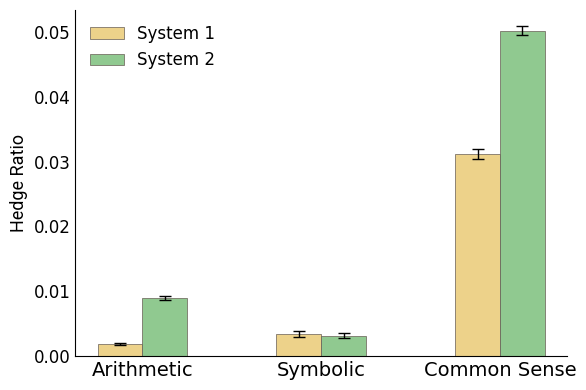

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import matplotlib.font_manager as fm


font_path = "/content/Roboto-Regular.ttf"
roboto_font_big = fm.FontProperties(fname=font_path, size=11)
roboto_font_med = fm.FontProperties(fname=font_path, size=13)
roboto_font_small = fm.FontProperties(fname=font_path, size=10)

# Define colors
sys1_color = "#fdda7a"
sys2_color = "#86d387"

# Create a list to store the data
plot_data = []

for ability in all_datasets_df["ability"].unique():
    sys1_values = all_datasets_df[f"sys1_second_hedge_ratio"][
        all_datasets_df["ability"] == ability
    ].values
    sys2_values = all_datasets_df[f"sys2_second_hedge_ratio"][
        all_datasets_df["ability"] == ability
    ].values

    # Compute means and standard errors
    sys1_mean, sys2_mean = np.mean(sys1_values), np.mean(sys2_values)
    sys1_sem, sys2_sem = (
        np.std(sys1_values, ddof=1) / np.sqrt(len(sys1_values)),
        np.std(sys2_values, ddof=1) / np.sqrt(len(sys2_values)),
    )

    # Store the results in a DataFrame-friendly format
    plot_data.append([ability, "System 1", sys1_mean, sys1_sem])
    plot_data.append([ability, "System 2", sys2_mean, sys2_sem])

# Convert to DataFrame
df_plot = pd.DataFrame(plot_data, columns=["Ability", "System", "Mean", "SEM"])

# Set figure size
plt.figure(figsize=(6, 4))
order = ["Arithmetic", "Symbolic", "Common Sense"]
# Plot with Seaborn

ax = sns.barplot(
    data=df_plot,
    x="Ability",
    y="Mean",
    hue="System",
    palette=[sys1_color, sys2_color],
    width=0.5,
    edgecolor="#665c53",
    linewidth=0.5,
    order=order
)

x_positions = []
for bars in ax.containers[:2]:
    for bar in bars:
        x_positions.append(bar.get_x() + bar.get_width() / 2)
yerr = [0.00017743,  0.00045837, 0.0007952,  0.00031009,  0.00039535, 0.00068924]
mean = [0.00183819, 0.003463, 0.03117516, 0.00896032, 0.00318257,  0.05014996]

for i, (pos, (_, row)) in enumerate(zip(x_positions, df_plot.iterrows())):
    ax.errorbar(
        x=pos,
        y=mean[i],
        yerr=yerr[i],
        fmt="none",
        color="black",
        capsize=4,
        capthick=1,
        linewidth=1
    )

# Remove borders
sns.despine(left=False, bottom=False)
ax.tick_params(axis='y', labelsize=12, length=0)
ax.tick_params(axis='x', labelsize=14, length=0)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)
plt.ylabel("Hedge Ratio", fontproperties=roboto_font_med)
plt.xlabel("")
plt.legend(loc="best", frameon=False, fontsize=12)
plt.tight_layout()
plt.savefig("hedge_ratio_second.png", dpi=900, bbox_inches="tight")

plt.show()

In [ ]:
df_plot["SEM"].values

array([0.0007952 , 0.00068924, 0.00017743, 0.00031009, 0.00045837,
       0.00039535])

In [ ]:
yerr = [0.00017743,  0.00045837, 0.0007952,  0.00031009,  0.00039535, 0.00068924]
mean = [0.00183819, 0.003463, 0.03117516, 0.00896032, 0.00318257,  0.05014996]

,Ability,System,Mean,SEM
0,Common Sense,System 1,0.031175,0.000795
1,Common Sense,System 2,0.050150,0.000689
2,Arithmetic,System 1,0.001838,0.000177
3,Arithmetic,System 2,0.008960,0.000310
4,Symbolic,System 1,0.003463,0.000458
5,Symbolic,System 2,0.003183,0.000395


In [ ]:
!pip install brokenaxes

In [ ]:
# get the points where the sys2 answer is correct but sys1 is not
sys2_better_df = merged_data[
    (merged_data["sys2_GT"] == merged_data["sys2_pred_after"])
    & (merged_data["sys1_GT"] != merged_data["sys1_pred_after"])
]

sys1_better_df = merged_data[
    (merged_data["sys1_GT"] == merged_data["sys1_pred_after"])
    & (merged_data["sys2_GT"] != merged_data["sys2_pred_after"])
]

sys21_both_correct = merged_data[
    (merged_data["sys2_GT"] == merged_data["sys2_pred_after"])
    & (merged_data["sys1_GT"] == merged_data["sys1_pred_after"])
]

sys21_both_incorrect = merged_data[
    (merged_data["sys2_GT"] != merged_data["sys2_pred_after"])
    & (merged_data["sys1_GT"] != merged_data["sys1_pred_after"])
]

In [ ]:
print(
    "Number of data points where both answers are correct:", sys21_both_correct.shape[0]
)
print(
    "Number of data points where both answers are incorrect:",
    sys21_both_incorrect.shape[0],
)
print("Number of data points where sys2 is better:", sys2_better_df.shape[0])
print("Number of data points where sys1 is better:", sys1_better_df.shape[0])

Number of data points where both answers are correct: 438
Number of data points where both answers are incorrect: 2
Number of data points where sys2 is better: 31
Number of data points where sys1 is better: 29


In [ ]:
print(
    "Ratio of data points where sys1 is better where the answer is yes: ",
    sys1_better_df[sys1_better_df["sys2_GT"] == "yes"].shape[0]
    / sys1_better_df.shape[0],
)

print(
    "Ratio of data points where sys2 is better where the answer is yes: ",
    sys2_better_df[sys2_better_df["sys2_GT"] == "yes"].shape[0]
    / sys2_better_df.shape[0],
)

Ratio of data points where sys1 is better where the answer is yes:  0.4827586206896552
Ratio of data points where sys2 is better where the answer is yes:  0.25806451612903225


In [ ]:
!pip install huggingface_hub

from huggingface_hub import notebook_login

notebook_login()

In [ ]:
import pandas as pd
from transformers import AutoTokenizer

df = pd.read_csv("/content/cogbias_before.csv")
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B-Instruct")

df["tokens_count"] = df["Answer"].apply(lambda x: len(tokenizer.tokenize(x)))

df.to_csv("cogbias_after_token.csv", index=False)

In [ ]:
df.head()

,Question,Answer,Strategy,tokens_count
0,Can we rely on your first impression of that p...,"Yes, my gut instinct is usually right.",system1,9
1,Do you think the initial price offered in nego...,"Yes, it seems like we always work around the f...",system1,14
2,Is your first estimate of how long a task will...,I tend to stick with my initial guess even if ...,system1,18
3,Does the first piece of information you hear a...,"Definitely, I can not help but compare everyth...",system1,15
4,"When you are given a salary range, does your e...","I always anchor to the higher end, even if it ...",system1,16


In [ ]:
list1 = df[df['Strategy'] == 'system1']['tokens_count'].tolist()
list2 = df[df['Strategy'] == 'system2']['tokens_count'].tolist()

print(len(list1))
print(len(list2))


2000
2000


In [ ]:

df_token = pd.DataFrame({'sys1 token': list1, 'sys2 token': list2})

df_token.to_csv('output_token_before.csv', index=False)

In [ ]:
df_token

,sys1 token,sys2 token
0,9,99
1,14,153
2,18,102
3,15,124
4,16,101
...,...,...
1995,18,131
1996,16,87
1997,21,111
1998,22,88
